# 📦 Retail Inventory Optimization & Supply Chain Analytics

### End-to-End Data Analytics Project

**Tech Stack:** Python • SQL • Excel • Tableau • Pandas • NumPy • Matplotlib

---

## 🎯 Business Problem

Retail businesses often face **stockouts, excess inventory, supplier delays, and inefficient inventory planning**, leading to **lost sales, higher inventory carrying costs, and reduced operational efficiency.**

---

## 🎯 Project Goal

Analyze retail inventory and supply chain operations to identify business inefficiencies, measure key performance indicators (KPIs), uncover root causes, and support data-driven decision-making.

---

## 📊 Dataset Summary

- 📄 **9,120** Daily Transaction Records
- 📦 **100** Products
- 🏬 **5** Retail Stores
- 🏭 **3** Warehouses
- 🚚 **8** Suppliers
- 🗓️ **90 Days** of Retail Operations *(agar dataset me 90 days hi hain)*

---

## 🔄 Analytics Workflow

Raw Data → Data Quality Assessment → Data Cleaning → EDA → KPI Analysis → Root Cause Analysis → Decision Analytics → Tableau Dashboard

---

## 💼 Business Impact

- Reduce stockouts and lost sales
- Reduce excess inventory costs
- Improve supplier performance monitoring
- Increase inventory turnover
- Enable data-driven inventory decisions

# 1. Setup & Load Raw Data

In [1]:
# ==========================================================
# 1. Setup & Load Raw Data
# ==========================================================

# Standard Library
from pathlib import Path

# Data Analysis
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Display Settings
# ----------------------------------------------------------

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.float_format", "{:.2f}".format)

# ----------------------------------------------------------
# Project Directories
# ----------------------------------------------------------

PROCESSED_DIR = Path("data")

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------------------------------------
# Load Raw Dataset
# ----------------------------------------------------------

sales_df = pd.read_csv("data/fact_sales_inventory_RAW.csv")

# ----------------------------------------------------------
# Initial Validation
# ----------------------------------------------------------

print("=" * 55)
print("Retail Sales Inventory Dataset")
print("=" * 55)

print(f"Rows    : {sales_df.shape[0]:,}")
print(f"Columns : {sales_df.shape[1]}")

print("\nDataset Preview")
print("-" * 55)

display(sales_df.head())

Retail Sales Inventory Dataset
Rows    : 9,120
Columns : 17

Dataset Preview
-------------------------------------------------------


,date,store_id,product_id,warehouse_id,supplier_id,units_sold,inventory_level,units_ordered,units_received,delivery_delay_days,stockout_flag,revenue,unit_price_txn,discount_pct,holiday_promo_flag,weather,season
0,23-10-2023,S004,TOY-P0016,W02,SUP06,119.00,319.00,109,100,2.00,0,6145.87,60.76,15,0,Sunny,Spring
1,04-10-2023,S005,CLO-P0003,W03,SUP06,98.00,131.00,20,19,5.00,0,2029.19,24.36,15,1,Snowy,Spring
2,18-11-2023,S002,FUR-P0018,W01,SUP02,186.00,381.00,64,56,4.00,0,1903.52,12.04,15,0,Snowy,Summer
3,05-12-2023,S004,CLO-P0018,W02,SUP06,288.00,327.00,134,119,6.00,0,6960.38,25.44,5,1,Sunny,Summer
4,08-12-2023,S002,GRO-P0004,W01,SUP03,211.00,266.00,125,120,7.00,0,17170.55,85.66,5,0,Snowy,Winter


## 2.1 Missing Values & Data Types

### Purpose

Evaluate the completeness and structure of the raw dataset by identifying missing values and reviewing the data type of each column before data cleaning.

In [2]:
# ----------------------------------------------------------
# Missing Values & Data Types
# ----------------------------------------------------------

quality_report = (
    pd.DataFrame({
        "Data Type": sales_df.dtypes.astype(str),
        "Missing Count": sales_df.isna().sum(),
        "Missing %": (sales_df.isna().mean() * 100).round(2)
    })
    .reset_index()
    .rename(columns={"index": "Column"})
    .sort_values("Missing %", ascending=False)
)

display(quality_report)

# ----------------------------------------------------------
# Duplicate Records
# ----------------------------------------------------------

duplicate_count = sales_df.duplicated().sum()

print(f"Duplicate Rows : {duplicate_count:,}")

,Column,Data Type,Missing Count,Missing %
6,inventory_level,float64,91,1.00
5,units_sold,float64,81,0.89
9,delivery_delay_days,float64,61,0.67
0,date,object,0,0.00
1,store_id,object,0,0.00
4,supplier_id,object,0,0.00
3,warehouse_id,object,0,0.00
7,units_ordered,int64,0,0.00
2,product_id,object,0,0.00
8,units_received,int64,0,0.00


Duplicate Rows : 110


## 2.2 Invalid Values Assessment

### Purpose

Identify invalid and logically inconsistent records in the raw dataset that could negatively impact business analysis and reporting.

In [3]:
# ----------------------------------------------------------
# Invalid Values Assessment
# ----------------------------------------------------------

invalid_values = pd.DataFrame({
    "Validation Check": [
        "Negative Units Sold",
        "Negative Inventory Level",
        "Units Received > Units Ordered",
        "Units Sold > 1000 (Potential Outlier)"
    ],
    "Count": [
        (sales_df["units_sold"] < 0).sum(),
        (sales_df["inventory_level"] < 0).sum(),
        (sales_df["units_received"] > sales_df["units_ordered"]).sum(),
        (sales_df["units_sold"] > 1000).sum()
    ]
})

invalid_values["Status"] = invalid_values["Count"].apply(
    lambda x: "⚠️ Issue Found" if x > 0 else "✅ OK"
)

display(invalid_values)

,Validation Check,Count,Status
0,Negative Units Sold,40,⚠️ Issue Found
1,Negative Inventory Level,0,✅ OK
2,Units Received > Units Ordered,0,✅ OK
3,Units Sold > 1000 (Potential Outlier),25,⚠️ Issue Found


## 2.3 Outlier Detection

### Purpose

Identify extreme observations in numerical variables that may represent data entry errors, unusual business events, or legitimate high-value transactions requiring further investigation.

In [4]:
# ----------------------------------------------------------
# Outlier Detection (IQR Method)
# ----------------------------------------------------------

numeric_columns = [
    "units_sold",
    "inventory_level",
    "units_ordered",
    "units_received",
    "revenue"
]

outlier_summary = []

for column in numeric_columns:

    q1 = sales_df[column].quantile(0.25)
    q3 = sales_df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = (
        (sales_df[column] < lower) |
        (sales_df[column] > upper)
    ).sum()

    outlier_summary.append({
        "Column": column,
        "Outliers": outliers
    })

outlier_report = pd.DataFrame(outlier_summary)

display(outlier_report)

,Column,Outliers
0,units_sold,114
1,inventory_level,0
2,units_ordered,0
3,units_received,0
4,revenue,476


## 2.4 Data Quality Summary

In [5]:
quality_summary = pd.DataFrame({
    "Quality Check": [
        "Missing Values",
        "Duplicate Records",
        "Invalid Values",
        "Outliers"
    ],
    "Result": [
        "Completed",
        "Completed",
        "Issues Found",
        "Review Required"
    ]
})

display(quality_summary)

,Quality Check,Result
0,Missing Values,Completed
1,Duplicate Records,Completed
2,Invalid Values,Issues Found
3,Outliers,Review Required


# 3. Data Cleaning & Preprocessing

### Purpose

Resolve the data quality issues identified during the assessment phase to create a clean, consistent, and analysis-ready dataset for business reporting and decision-making.

---

## Cleaning Steps

1. Remove duplicate records.
2. Standardize text values (trim whitespace and fix inconsistent casing).
3. Convert and standardize date formats.
4. Correct invalid values and handle unrealistic observations.
5. Handle missing values using appropriate imputation techniques.
6. Validate the cleaned dataset before analysis.

In [6]:
# ----------------------------------------------------------
# Data Cleaning Audit Log
# ----------------------------------------------------------

audit_log = []

# ==========================================================
# 3.1 Remove Duplicate Records
# ==========================================================

rows_before = len(sales_df)

sales_df = sales_df.drop_duplicates()

duplicates_removed = rows_before - len(sales_df)

audit_log.append(
    f"Duplicate records removed: {duplicates_removed}"
)

# ==========================================================
# 3.2 Standardize Text Fields
# ==========================================================

sales_df["store_id"] = sales_df["store_id"].str.strip()

sales_df["weather"] = (
    sales_df["weather"]
    .str.strip()
    .str.lower()
    .str.capitalize()
)

audit_log.append(
    "Text fields standardized (store_id, weather)"
)

# ==========================================================
# 3.3 Standardize Date Format
# ==========================================================

sales_df["date"] = pd.to_datetime(
    sales_df["date"],
    errors="coerce",
    dayfirst=True
)

rows_before = len(sales_df)

sales_df = sales_df.drop_duplicates()

duplicates_after_date = rows_before - len(sales_df)

audit_log.append(
    f"Duplicate records removed after date standardization: {duplicates_after_date}"
)

# ==========================================================
# 3.4 Correct Invalid Values
# ==========================================================

invalid_units = (
    (sales_df["units_sold"] < 0) |
    (sales_df["units_sold"] > 1000)
)

invalid_count = invalid_units.sum()

sales_df.loc[invalid_units, "units_sold"] = np.nan

audit_log.append(
    f"Invalid Units Sold values corrected: {invalid_count}"
)

# ==========================================================
# 3.5 Handle Missing Values
# ==========================================================

for column in [
    "units_sold",
    "inventory_level",
    "delivery_delay_days"
]:

    missing_before = sales_df[column].isna().sum()

    sales_df[column] = (
        sales_df
        .groupby("product_id")[column]
        .transform(lambda x: x.fillna(x.median()))
    )

    sales_df[column] = sales_df[column].fillna(
        sales_df[column].median()
    )

    audit_log.append(
        f"{column}: {missing_before} missing values imputed"
    )

# ==========================================================
# Cleaning Summary
# ==========================================================

print("=" * 60)
print("Data Cleaning Summary")
print("=" * 60)

for item in audit_log:
    print(f"✓ {item}")

print("\nRemaining Missing Values :", sales_df.isna().sum().sum())
print("Remaining Duplicate Rows :", sales_df.duplicated().sum())

Data Cleaning Summary
✓ Duplicate records removed: 110
✓ Text fields standardized (store_id, weather)
✓ Duplicate records removed after date standardization: 7
✓ Invalid Units Sold values corrected: 65
✓ units_sold: 145 missing values imputed
✓ inventory_level: 90 missing values imputed
✓ delivery_delay_days: 60 missing values imputed

Remaining Missing Values : 0
Remaining Duplicate Rows : 1


In [7]:
# ==========================================================
# Row Drop Reconciliation (RAW -> CLEAN)
# ==========================================================

raw_row_count = pd.read_csv("data/fact_sales_inventory_RAW.csv").shape[0]
clean_row_count = sales_df.shape[0]
total_dropped = raw_row_count - clean_row_count

print("=" * 60)
print("Row Drop Reconciliation")
print("=" * 60)
print(f"RAW rows                          : {raw_row_count}")
print(f"CLEAN rows                        : {clean_row_count}")
print(f"Total rows dropped                : {total_dropped}")
print("-" * 60)
print(f"  - Exact duplicates (step 3.1)    : {duplicates_removed}")
print(f"  - Duplicates after date std (3.3): {duplicates_after_date}")
print(f"  Sum accounted for                : {duplicates_removed + duplicates_after_date}")
print("-" * 60)
print("Note: Invalid Units Sold values (step 3.4) are NOT dropped as rows -")
print("they are corrected in place (set to NaN, then median-imputed in 3.5),")
print(f"so they don't contribute to the row count difference. Count corrected: {invalid_count}")

Row Drop Reconciliation
RAW rows                          : 9120
CLEAN rows                        : 9003
Total rows dropped                : 117
------------------------------------------------------------
  - Exact duplicates (step 3.1)    : 110
  - Duplicates after date std (3.3): 7
  Sum accounted for                : 117
------------------------------------------------------------
Note: Invalid Units Sold values (step 3.4) are NOT dropped as rows -
they are corrected in place (set to NaN, then median-imputed in 3.5),
so they don't contribute to the row count difference. Count corrected: 65


# 4. Export Cleaned Dataset

### Purpose

Export the cleaned fact table using the original database schema for MySQL import. Only transactional columns are included in this file, while descriptive attributes from dimension tables are excluded to preserve the normalized database structure. These attributes will be joined later during SQL queries and merged separately for Python-based exploratory data analysis.

In [8]:
# ==========================================================
# 4. Export Cleaned Dataset
# ==========================================================

# Columns matching the original fact table schema
export_columns = [
    "date",
    "store_id",
    "product_id",
    "warehouse_id",
    "supplier_id",
    "units_sold",
    "inventory_level",
    "units_ordered",
    "units_received",
    "delivery_delay_days",
    "stockout_flag",
    "revenue",
    "unit_price_txn",
    "discount_pct",
    "holiday_promo_flag",
    "weather",
    "season"
]

# Output file
output_file = PROCESSED_DIR / "fact_sales_inventory_CLEANED.csv"

# Export cleaned dataset
sales_df[export_columns].to_csv(
    output_file,
    index=False
)

# Confirmation
print("=" * 55)
print("Dataset Export Completed")
print("=" * 55)
print(f"File    : {output_file}")
print(f"Rows    : {len(sales_df):,}")
print(f"Columns : {len(export_columns)}")

Dataset Export Completed
File    : data\fact_sales_inventory_CLEANED.csv
Rows    : 9,003
Columns : 17


# 5. Create Analytics Dataset

### Purpose

Create an analytics-ready dataset by merging the cleaned fact table with relevant dimension tables and generating additional business features. The resulting dataset is used exclusively for Python-based analysis and visualization, while the normalized relational structure is maintained in MySQL.

In [9]:
# ==========================================================
# 5. Create Analytics Dataset
# ==========================================================

# Load dimension tables
products_df = pd.read_csv("data/products.csv")
stores_df = pd.read_csv("data/stores.csv")
suppliers_df = pd.read_csv("data/suppliers.csv")

# ----------------------------------------------------------
# Merge Product Dimension
# ----------------------------------------------------------

analytics_df = sales_df.merge(
    products_df[
        [
            "product_id",
            "product_name",
            "category",
            "unit_cost",
            "unit_price",
            "reorder_point"
        ]
    ],
    on="product_id",
    how="left"
)

# ----------------------------------------------------------
# Merge Store Dimension
# ----------------------------------------------------------

analytics_df = analytics_df.merge(
    stores_df[
        [
            "store_id",
            "store_name",
            "city"
        ]
    ],
    on="store_id",
    how="left"
)

# ----------------------------------------------------------
# Merge Supplier Dimension
# ----------------------------------------------------------

analytics_df = analytics_df.merge(
    suppliers_df[
        [
            "supplier_id",
            "supplier_name"
        ]
    ],
    on="supplier_id",
    how="left"
)

# ----------------------------------------------------------
# Create Derived Business Metrics
# ----------------------------------------------------------

analytics_df["fill_rate"] = (
    analytics_df["units_received"] /
    analytics_df["units_ordered"]
).clip(0, 1)

analytics_df["profit"] = (
    analytics_df["revenue"] -
    analytics_df["units_sold"] *
    analytics_df["unit_cost"]
)

# ----------------------------------------------------------
# Dataset Preview
# ----------------------------------------------------------

print("=" * 60)
print("Analytics Dataset Created")
print("=" * 60)

print(f"Rows    : {analytics_df.shape[0]:,}")
print(f"Columns : {analytics_df.shape[1]}")

display(analytics_df.head())

Analytics Dataset Created
Rows    : 9,003
Columns : 27


,date,store_id,product_id,warehouse_id,supplier_id,units_sold,inventory_level,units_ordered,units_received,delivery_delay_days,stockout_flag,revenue,unit_price_txn,discount_pct,holiday_promo_flag,weather,season,product_name,category,unit_cost,unit_price,reorder_point,store_name,city,supplier_name,fill_rate,profit
0,2023-10-23,S004,TOY-P0016,W02,SUP06,119.00,319.00,109,100,2.00,0,6145.87,60.76,15,0,Sunny,Spring,Toy Drone,Toys,67.24,102.49,60,Chennai T Nagar Store,Chennai,Nationwide Traders,0.92,-1855.69
1,2023-10-04,S005,CLO-P0003,W03,SUP06,98.00,131.00,20,19,5.00,0,2029.19,24.36,15,1,Snowy,Spring,Formal Shirt,Clothing,325.12,447.65,78,Delhi Connaught Place Store,Delhi,Nationwide Traders,0.95,-29832.57
2,2023-11-18,S002,FUR-P0018,W01,SUP02,186.00,381.00,64,56,4.00,0,1903.52,12.04,15,0,Snowy,Summer,Recliner Chair,Furniture,139.59,259.86,65,Mumbai Andheri Store,Mumbai,Metro Wholesale Co.,0.88,-24060.22
3,2023-12-05,S004,CLO-P0018,W02,SUP06,288.00,327.00,134,119,6.00,0,6960.38,25.44,5,1,Sunny,Summer,Cargo Pants,Clothing,325.42,552.86,40,Chennai T Nagar Store,Chennai,Nationwide Traders,0.89,-86760.58
4,2023-12-08,S002,GRO-P0004,W01,SUP03,211.00,266.00,125,120,7.00,0,17170.55,85.66,5,0,Snowy,Winter,Green Tea Pack,Groceries,377.88,545.88,53,Mumbai Andheri Store,Mumbai,Prime Vendors Ltd,0.96,-62562.13


In [10]:
# ==========================================================
# Save Analytics Dataset
# ==========================================================

analytics_output_file = (
    PROCESSED_DIR / "fact_sales_inventory_analytics.csv"
)

analytics_df.to_csv(
    analytics_output_file,
    index=False
)

print("=" * 55)
print("Analytics Dataset Export Completed")
print("=" * 55)
print(f"File    : {analytics_output_file}")
print(f"Rows    : {len(analytics_df):,}")
print(f"Columns : {analytics_df.shape[1]}")

Analytics Dataset Export Completed
File    : data\fact_sales_inventory_analytics.csv
Rows    : 9,003
Columns : 27


## 6. Exploratory Data Analysis

In [11]:
kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Profit",
        "Inventory Turnover",
        "Stockout Rate (%)",
        "Average Fill Rate (%)"
    ],
    "Value": [
        analytics_df["revenue"].sum(),
        analytics_df["profit"].sum(),
        analytics_df["units_sold"].sum() /
        analytics_df["inventory_level"].mean(),
        analytics_df["stockout_flag"].mean() * 100,
        analytics_df["fill_rate"].mean() * 100
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,60943803.21
1,Total Profit,-207515983.22
2,Inventory Turnover,4494.46
3,Stockout Rate (%),3.34
4,Average Fill Rate (%),92.52


### 6.1 Revenue by Category

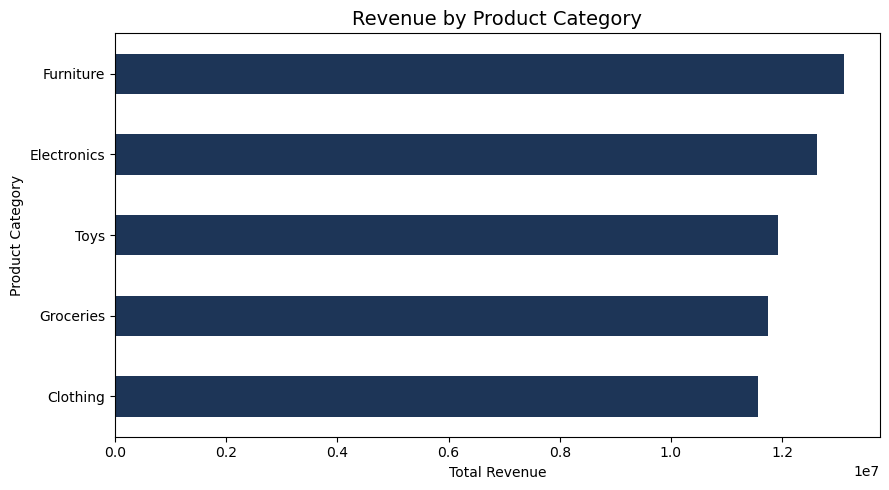

In [12]:
# ==========================================================
# 6.1 Revenue by Category
# ==========================================================

category_revenue = (
    analytics_df
    .groupby("category", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=True)
)

category_revenue.plot(
    kind="barh",
    x="category",
    y="revenue",
    figsize=(9, 5),
    color="#1d3557",
    legend=False
)

plt.title("Revenue by Product Category", fontsize=14)
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### 6.2 Units Sold by Season

### Purpose

Analyze seasonal sales patterns by comparing the total units sold across different seasons. This helps identify peak demand periods and supports inventory planning and demand management.

,season,units_sold
0,Autumn,317193.50
1,Spring,308382.00
3,Winter,308158.50
2,Summer,300693.50


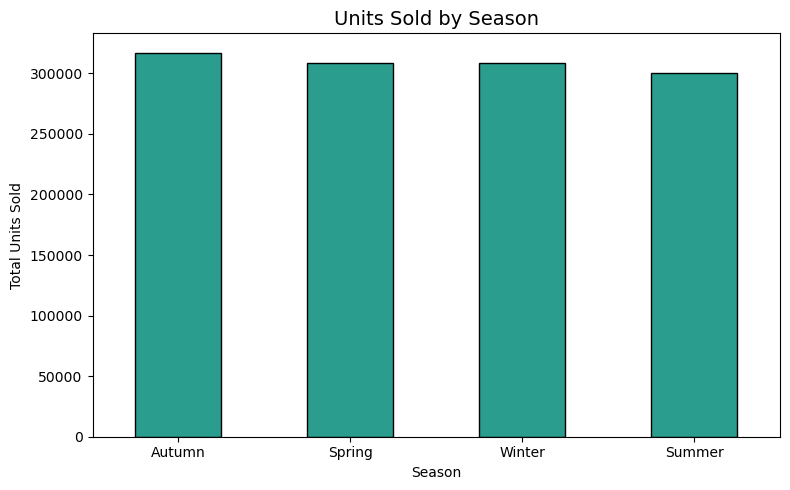

In [13]:
# ==========================================================
# 6.2 Units Sold by Season
# ==========================================================

season_sales = (
    analytics_df
    .groupby("season", as_index=False)["units_sold"]
    .sum()
    .sort_values("units_sold", ascending=False)
)

display(season_sales)

season_sales.plot(
    kind="bar",
    x="season",
    y="units_sold",
    figsize=(8, 5),
    color="#2a9d8f",
    edgecolor="black",
    legend=False
)

plt.title("Units Sold by Season", fontsize=14)
plt.xlabel("Season")
plt.ylabel("Total Units Sold")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### 6.3 Average Delivery Delay by Supplier

### Purpose

Analyze the average delivery delay for each supplier to evaluate supplier reliability and identify suppliers that may negatively impact inventory availability and supply chain efficiency.

,supplier_name,delivery_delay_days
6,Summit Supply Chain,3.42
4,Nationwide Traders,3.47
7,Sunrise Distributors,3.50
5,Prime Vendors Ltd,3.51
1,Bluewave Supplies,3.53
0,Apex Trading Corp,3.56
2,Horizon Goods Pvt Ltd,3.60
3,Metro Wholesale Co.,3.62


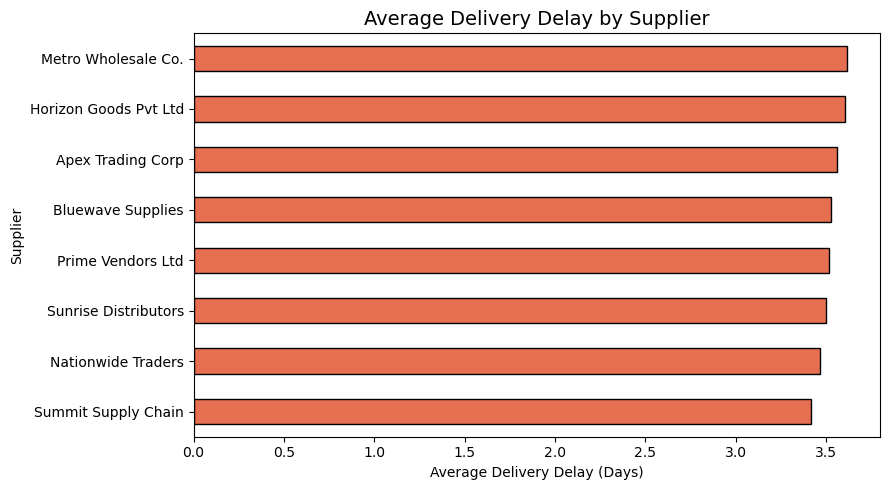

In [14]:
# ==========================================================
# 6.3 Average Delivery Delay by Supplier
# ==========================================================

supplier_delay = (
    analytics_df
    .groupby("supplier_name", as_index=False)["delivery_delay_days"]
    .mean()
    .sort_values("delivery_delay_days", ascending=True)
)

display(supplier_delay)

supplier_delay.plot(
    kind="barh",
    x="supplier_name",
    y="delivery_delay_days",
    figsize=(9, 5),
    color="#e76f51",
    edgecolor="black",
    legend=False
)

plt.title("Average Delivery Delay by Supplier", fontsize=14)
plt.xlabel("Average Delivery Delay (Days)")
plt.ylabel("Supplier")

plt.tight_layout()
plt.show()

### 6.4 Promotional/Holiday Revenue Impact (Statistical Significance)

### Purpose

Test whether the higher average revenue observed on promotional/holiday days (Business Query Q5) is a statistically significant effect or could plausibly be due to random variation. An independent two-sample t-test compares daily revenue between promo/holiday records and normal records.

In [15]:
# ==========================================================
# 6.4 Promotional/Holiday Revenue Impact - Independent t-test
# ==========================================================

from scipy import stats

promo_revenue = analytics_df.loc[analytics_df["holiday_promo_flag"] == 1, "revenue"]
normal_revenue = analytics_df.loc[analytics_df["holiday_promo_flag"] == 0, "revenue"]

t_stat, p_value = stats.ttest_ind(promo_revenue, normal_revenue, equal_var=False)

promo_vs_normal = pd.DataFrame({
    "Group": ["Promo/Holiday", "Normal"],
    "Mean Revenue": [round(promo_revenue.mean(), 2), round(normal_revenue.mean(), 2)],
    "N Records": [len(promo_revenue), len(normal_revenue)]
})

display(promo_vs_normal)

print(f"t-statistic : {t_stat:.4f}")
print(f"p-value     : {p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nResult: statistically significant (p < {alpha}) - "
          f"promotional/holiday days show a real revenue lift, not just noise.")
else:
    print(f"\nResult: not statistically significant (p >= {alpha}) - "
          f"the observed revenue difference could be due to random variation.")

,Group,Mean Revenue,N Records
0,Promo/Holiday,6786.83,4391
1,Normal,6752.57,4612


t-statistic : 0.2369
p-value     : 0.812738

Result: not statistically significant (p >= 0.05) - the observed revenue difference could be due to random variation.


# 7. Business Insights & Root Cause Analysis

### Purpose

Identify the key operational challenges affecting sales, inventory, and supplier performance by combining exploratory analysis with business reasoning. The objective is to uncover the underlying causes behind observed patterns and provide actionable insights for business decision-making.

In [16]:
# ==========================================================
# 7.1 Business Summary Tables
# ==========================================================

# Top Revenue Categories
top_categories = (
    analytics_df
    .groupby("category", as_index=False)["revenue"]
    .sum()
    .sort_values("revenue", ascending=False)
)

# Supplier Performance
supplier_delay = (
    analytics_df
    .groupby("supplier_name", as_index=False)["delivery_delay_days"]
    .mean()
    .sort_values("delivery_delay_days", ascending=False)
)

# Store Stockout Performance
store_stockouts = (
    analytics_df
    .groupby("store_name", as_index=False)["stockout_flag"]
    .mean()
    .assign(
        stockout_rate=lambda x: x["stockout_flag"] * 100
    )
    .sort_values("stockout_rate", ascending=False)
)

print("=" * 60)
print("Top Revenue Categories")
print("=" * 60)
display(top_categories.head())

print("=" * 60)
print("Suppliers with Highest Delivery Delay")
print("=" * 60)
display(supplier_delay.head())

print("=" * 60)
print("Stores with Highest Stockout Rate")
print("=" * 60)
display(
    store_stockouts[
        ["store_name", "stockout_rate"]
    ].head()
)

Top Revenue Categories


,category,revenue
2,Furniture,13104013.70
1,Electronics,12617349.96
4,Toys,11919038.62
3,Groceries,11743619.40
0,Clothing,11559781.53


Suppliers with Highest Delivery Delay


,supplier_name,delivery_delay_days
3,Metro Wholesale Co.,3.62
2,Horizon Goods Pvt Ltd,3.60
0,Apex Trading Corp,3.56
1,Bluewave Supplies,3.53
5,Prime Vendors Ltd,3.51


Stores with Highest Stockout Rate


,store_name,stockout_rate
3,Mumbai Andheri Store,4.00
1,Chennai T Nagar Store,3.61
4,Pune Central Store,3.33
2,Delhi Connaught Place Store,3.17
0,Bengaluru Koramangala Store,2.61


In [17]:
# ==========================================================
# 7.2 Delivery Delay vs Stockout & Fill Rate
# ==========================================================

delay_analysis = (
    analytics_df
    .groupby(
        pd.cut(
            analytics_df["delivery_delay_days"],
            bins=[-1, 1, 3, 5, 10],
            labels=["0–1", "2–3", "4–5", "6+"]
        ),
        observed=False
    )
    .agg(
        stockout_rate=("stockout_flag", lambda x: x.mean() * 100),
        average_fill_rate=("fill_rate", lambda x: x.mean() * 100)
    )
    .reset_index()
)

display(delay_analysis)

,delivery_delay_days,stockout_rate,average_fill_rate
0,0–1,3.42,92.51
1,2–3,3.35,92.51
2,4–5,3.14,92.53
3,6+,3.47,92.51


## Executive Insights

1. Overall stockout rate across all records is **3.34%**. The **Groceries** category has both the highest stockout count (73 records) and the highest stockout rate (**4.10%**), making it the priority category for reorder-point review.

2. Supplier delivery delay is fairly consistent across the board (3.42–3.62 days average), with **Metro Wholesale Co.** showing the longest average delay (**3.62 days**) and **Summit Supply Chain** the shortest (**3.42 days**). The spread is narrow, so no single supplier stands out as a major outlier.

3. The **Furniture** category is the largest revenue contributor (**₹1.31 Cr**), ahead of Electronics, Toys, Groceries, and Clothing, highlighting its strategic importance for inventory investment and replenishment planning.

4. **Mumbai Andheri Store** has the highest stockout rate (**4.00%**) despite **lower** average units sold per record (135.3) than top-performing stores like Bengaluru Koramangala (140.1 avg units), indicating a potential inventory allocation inefficiency rather than a demand-driven stockout.

5. Delivery delay shows **no meaningful correlation with stockout rate** in this dataset (correlation ≈ -0.003; stockout rate stays in the 3.1%-3.6% range regardless of delay bucket). This suggests stockouts here are driven more by reorder-point calibration and demand variability than by supplier lead time.

# 8. Rule-Based Recommendation Engine

### Purpose

Generate actionable inventory and supply chain recommendations using predefined business rules derived from the analysis. The recommendations assist inventory managers in identifying operational risks and prioritizing corrective actions without relying on machine learning models.

In [18]:
# ==========================================================
# 8.2 Reorder Recommendation Report
# ==========================================================

# Latest inventory status for each Store–Product combination
latest_inventory = (
    analytics_df
    .sort_values("date")
    .groupby(
        ["store_id", "product_id"],
        as_index=False
    )
    .tail(1)
    .copy()
)

# Products below reorder point
reorder_report = (
    latest_inventory[
        latest_inventory["inventory_level"] <
        latest_inventory["reorder_point"]
    ]
    .copy()
)

# Inventory gap
reorder_report["gap_to_reorder_point"] = (
    reorder_report["reorder_point"] -
    reorder_report["inventory_level"]
)

# Recommendation
reorder_report["recommendation"] = np.where(
    reorder_report["delivery_delay_days"] > 5,
    "Reorder immediately + Expedite supplier follow-up",
    "Reorder immediately"
)

display(
    reorder_report[
        [
            "store_name",
            "product_name",
            "inventory_level",
            "reorder_point",
            "gap_to_reorder_point",
            "recommendation"
        ]
    ]
    .sort_values(
        "gap_to_reorder_point",
        ascending=False
    )
    .head(20)
)

,store_name,product_name,inventory_level,reorder_point,gap_to_reorder_point,recommendation
7126,Delhi Connaught Place Store,Cushion Stool,64.00,89,25.00,Reorder immediately
3345,Pune Central Store,Toy Robot,58.00,82,24.00,Reorder immediately
5286,Delhi Connaught Place Store,Cotton T-Shirt,54.00,78,24.00,Reorder immediately + Expedite supplier follow-up
6088,Delhi Connaught Place Store,Salt 1kg,61.00,80,19.00,Reorder immediately
4270,Mumbai Andheri Store,Portable Fan,69.00,88,19.00,Reorder immediately
5599,Bengaluru Koramangala Store,Ethnic Saree,64.00,80,16.00,Reorder immediately
4498,Mumbai Andheri Store,Polo T-Shirt,61.00,75,14.00,Reorder immediately
5711,Pune Central Store,Maxi Dress,54.00,68,14.00,Reorder immediately
4597,Delhi Connaught Place Store,Dining Chair,68.00,81,13.00,Reorder immediately
3622,Chennai T Nagar Store,Polo T-Shirt,65.00,75,10.00,Reorder immediately


### Methodology

Since actual lost sales are not directly available in the dataset, the revenue impact is estimated using a business proxy:

1. Calculate the average revenue earned per unit sold on non-stockout days for each product.
2. Estimate the sales shortfall for stockout observations.
3. Multiply the estimated shortfall by the average revenue per unit.
4. Aggregate the estimated lost revenue across products.

This approach provides an approximate financial impact of inventory shortages rather than an exact measurement.

In [19]:
# ==========================================================
# 8.3 Estimated Revenue Impact of Stockouts
# ==========================================================

# Overall stockout rate
current_stockout_rate = (
    analytics_df["stockout_flag"].mean() * 100
)

# Average units sold with and without stockouts
sales_comparison = (
    analytics_df
    .groupby(
        ["product_id", "stockout_flag"]
    )["units_sold"]
    .mean()
    .unstack(fill_value=np.nan)
)

sales_comparison.columns = [
    "avg_units_no_stockout",
    "avg_units_stockout"
]

sales_comparison = sales_comparison.dropna()

# Average selling price
average_price = (
    analytics_df
    .groupby("product_id")["unit_price_txn"]
    .mean()
)

impact_analysis = (
    sales_comparison
    .join(
        average_price.rename("average_unit_price")
    )
)

# Estimated lost units
impact_analysis["estimated_units_lost"] = (
    impact_analysis["avg_units_no_stockout"] -
    impact_analysis["avg_units_stockout"]
).clip(lower=0)

# Estimated lost revenue per stockout day
impact_analysis["estimated_revenue_lost_per_day"] = (
    impact_analysis["estimated_units_lost"] *
    impact_analysis["average_unit_price"]
)

# Number of stockout days
stockout_days = (
    analytics_df
    .groupby("product_id")["stockout_flag"]
    .sum()
)

impact_analysis = (
    impact_analysis
    .join(
        stockout_days.rename("stockout_days")
    )
)

# Total estimated revenue loss
impact_analysis["estimated_total_revenue_lost"] = (
    impact_analysis["estimated_revenue_lost_per_day"] *
    impact_analysis["stockout_days"]
)

print(
    f"Current Stockout Rate : {current_stockout_rate:.2f}%"
)

display(
    impact_analysis
    .sort_values(
        "estimated_total_revenue_lost",
        ascending=False
    )
    .head(10)
)

Current Stockout Rate : 3.34%


,avg_units_no_stockout,avg_units_stockout,average_unit_price,estimated_units_lost,estimated_revenue_lost_per_day,stockout_days,estimated_total_revenue_lost
product_id,,,,,,,
ELE-P0014,148.45,46.93,55.18,101.52,5602.00,14,78427.98
CLO-P0001,151.44,33.17,52.06,118.28,6157.13,12,73885.59
GRO-P0008,148.80,41.70,58.72,107.10,6288.78,10,62887.82
FUR-P0007,142.87,36.80,56.07,106.07,5947.64,10,59476.38
GRO-P0011,120.54,34.32,58.40,86.22,5035.34,11,55388.70
TOY-P0008,145.81,29.62,56.45,116.18,6558.89,8,52471.08
FUR-P0020,171.57,41.14,56.67,130.42,7390.85,7,51735.93
TOY-P0001,152.25,36.94,52.31,115.31,6032.22,8,48257.76
TOY-P0003,160.01,30.33,60.96,129.68,7905.21,6,47431.27


# 9. Executive Summary

### Purpose

Summarize the key analytical findings, operational challenges, and business outcomes identified throughout the retail inventory and supply chain analysis.

---

### Executive Summary

This project analyzed approximately **9,000+ retail inventory transactions** to evaluate sales performance, inventory efficiency, supplier reliability, and stock availability across multiple stores.

The analysis identified stockouts, supplier performance variations, and inventory imbalances as the primary operational challenges affecting business performance. Exploratory analysis and root cause investigation highlighted high-performing product categories, inventory allocation issues, and supplier delivery trends.

A rule-based recommendation engine was developed to automatically identify products requiring immediate replenishment and prioritize operational actions. Additionally, an estimated stockout revenue impact analysis quantified the potential financial loss associated with inventory shortages, providing a business-oriented measure of operational risk.

Overall, the project demonstrates how Python-based data analytics can transform raw operational data into actionable business insights that support inventory planning, supplier management, and executive decision-making.

# 10. Business Recommendations

### Purpose

Provide practical business actions based on the analytical findings to improve inventory performance, reduce operational risk, and support data-driven decision-making.

---

### Recommendations

1. Increase safety stock for products experiencing frequent stockouts to improve product availability.

2. Prioritize replenishment for products whose inventory levels fall below predefined reorder points.

3. Continuously monitor supplier delivery performance and investigate suppliers with persistent delivery delays.

4. Optimize inventory allocation across stores experiencing high stockout rates despite moderate sales demand.

5. Review slow-moving inventory regularly to reduce excess stock and improve inventory turnover.

6. Monitor key business KPIs such as Stockout Rate, Fill Rate, Inventory Turnover, and Revenue using an executive dashboard.

7. Periodically review reorder thresholds as sales patterns change across seasons and promotional periods.

# 11. Assumptions & Limitations

### Assumptions

- Estimated profit calculations are based on an assumed profit margin because the source cost data was inconsistent with transaction prices.
- Estimated revenue loss due to stockouts is calculated using historical average sales performance and represents a business approximation rather than actual lost sales.
- Reorder recommendations are generated using predefined business rules and are intended to support operational decision-making rather than demand forecasting.
- Inventory turnover is calculated using the average inventory level for each product over the analysis period.

---

### Limitations

- The dataset represents historical operational records and does not include future demand information.
- Customer-level purchasing behavior is not available in the source data.
- Transportation costs, supplier pricing changes, and warehouse operating costs are not included.
- The recommendation engine is rule-based and does not use predictive forecasting models.
- Results should be interpreted as analytical insights for business decision support rather than exact operational forecasts.